# LeR model uncertainty example

This notebook is created by [Phurailatpam Hemantakumar](https://hemantaph.com).

[![Documentation](https://img.shields.io/badge/ler-documentation-blue)](https://ler.hemantaph.com)

This notebook demonstrates how to propagate source-population hyperparameter uncertainty into **LeR** unlensed and lensed rate predictions. We use posterior samples of the broken powerlaw + two peaks mass model, compare a median-hyperparameter baseline against posterior draws, and visualize the resulting uncertainty in rates and mass distributions.

## Table of Contents

1. [Part 1: Load Hyperparameter Posterior and Inspect Inputs](#part-1-load-hyperparameter-posterior-and-inspect-inputs)
2. [Part 2: Define Baseline Sampler and Initialize LeR](#part-2-define-baseline-sampler-and-initialize-ler)
3. [Part 3: Median-Hyperparameter Baseline Run](#part-3-median-hyperparameter-baseline-run)
4. [Part 4: Posterior Propagation Across Hyperparameter Draws](#part-4-posterior-propagation-across-hyperparameter-draws)
5. [Part 5: Visualize Uncertainty in Rates and Mass Distribution](#part-5-visualize-uncertainty-in-rates-and-mass-distribution)
6. [Summary](#summary)

---

## Part 1: Load Hyperparameter Posterior and Inspect Inputs

### 1.1 Load Posterior Samples of Mass Model Hyperparameters

- This data is resampled from the original GWTC-4 posterior, within the 90% credible interval, to reduce runtime for this example. 

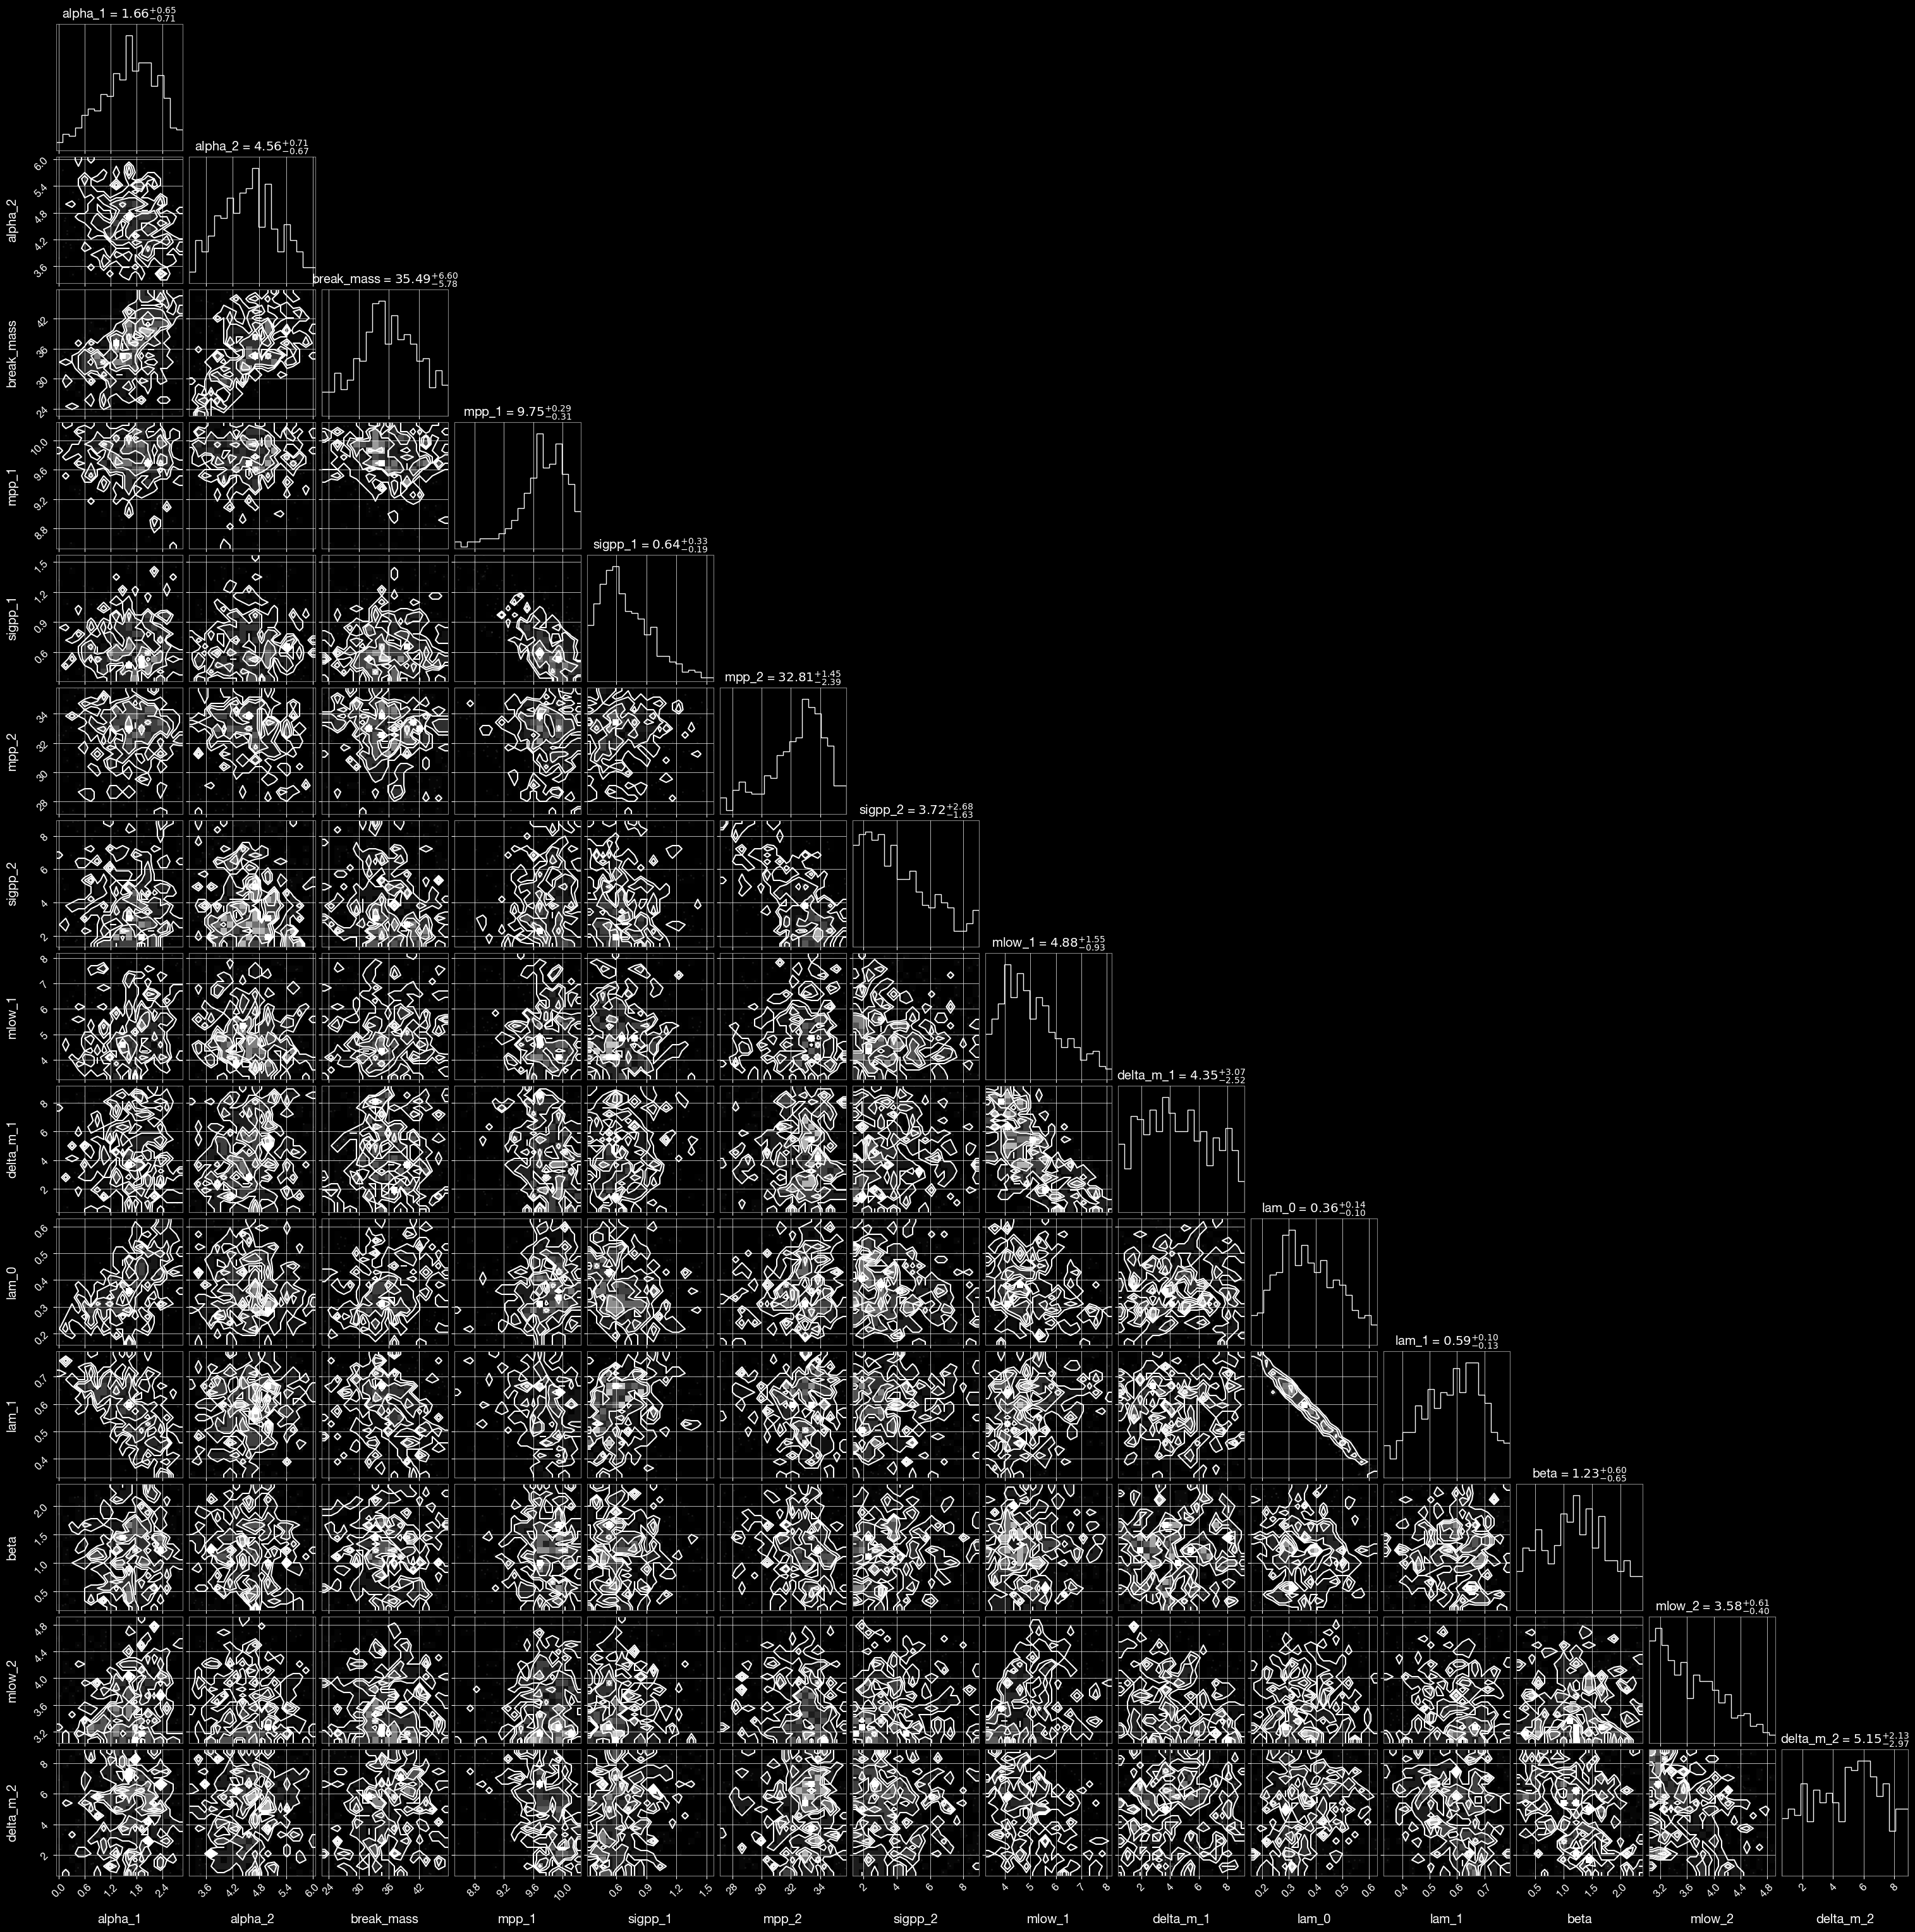

In [1]:
# load data 
from ler.utils import get_param_from_json
from corner import corner
import numpy as np

# 500 samples from the 90% credible interval of the hyperparameters of the broken powerlaw plus 2 peaks model from GWTC-4
data = get_param_from_json("broken_powerlaw_plus_2peaks_hyperparameters.json")
# data

# plot the corner plot of the hyperparameters
labels = list(data.keys())
# use column stacks
data_ = np.column_stack([data[key] for key in labels])

figure = corner(data_, labels=labels, show_titles=True)


### 1.2 Summarize posterior medians

Estimate representative (median) values of each hyperparameter. These medians are used to build a single baseline run for comparison against posterior draws.

In [2]:
# let's get the median value of each parameter
median_value = dict()
for key in data.keys():
    median_value[key] = np.median(data[key])
    print(f"{key}: {median_value[key]:.2f}")

alpha_1: 1.66
alpha_2: 4.56
break_mass: 35.49
mpp_1: 9.75
sigpp_1: 0.64
mpp_2: 32.81
sigpp_2: 3.72
mlow_1: 4.88
delta_m_1: 4.35
lam_0: 0.36
lam_1: 0.59
beta: 1.23
mlow_2: 3.58
delta_m_2: 5.15


### 1.3 Inspect the source-mass sampler

Review the sampler docstring to confirm parameter definitions and expected behavior before constructing LeR priors.

In [3]:
# get the function
from ler.gw_source_population import broken_powerlaw_plus_2peaks_rvs

print(broken_powerlaw_plus_2peaks_rvs.__doc__)


    Generate random samples from the primary-mass distribution.

    Draws random samples using inverse transform sampling applied to the CDF,
    which is computed using numerically stable log-space integration.

    Parameters
    ----------
    size : ``int``
        Number of samples to generate.
    lam_0, lam_1, mpp_1, sigpp_1, mpp_2, sigpp_2, mlow_1, delta_m_1, break_mass, alpha_1, alpha_2, mmax : ``float``
        Distribution parameters.
        +------------+---------+-----------------------------------------------------------+
        | param      | default | description                                               |
        +============+=========+===========================================================+
        | lam_0      | 0.361   | Fraction of broken power-law component (0 <= lam_0 <= 1)  |
        +------------+---------+-----------------------------------------------------------+
        | lam_1      | 0.586   | Fraction of first Gaussian peak (0 <= lam_1 <= 1) 

---

## Part 2: Define Baseline Sampler and Initialize LeR

### 2.1 Median-hyperparameter mass sampler

Define a mass sampler with fixed median hyperparameters. This provides a consistent baseline model for comparison with posterior-propagated runs.

In [8]:
from ler import LeR
import numpy as np
import matplotlib.pyplot as plt
import contextlib
from tqdm import tqdm

# median value of the hyperparameters
mass_1_source_rvs = lambda size: broken_powerlaw_plus_2peaks_rvs(
    size=size,
    lam_0=np.median(data["lam_0"]),
    lam_1=np.median(data["lam_1"]),
    mpp_1=np.median(data["mpp_1"]),
    sigpp_1=np.median(data["sigpp_1"]),
    mpp_2=np.median(data["mpp_2"]),
    sigpp_2=np.median(data["sigpp_2"]),
    mlow_1=np.median(data["mlow_1"]),
    delta_m_1=np.median(data["delta_m_1"]),
    break_mass=np.median(data["break_mass"]),   
    alpha_1=np.median(data["alpha_1"]),
    alpha_2=np.median(data["alpha_2"]),
    mmax=300.0,
)

### 2.2 Initialize LeR

Instantiate LeR with the custom median-hyperparameter mass prior and default BBH lensing settings.

In [9]:
ler = LeR(
    npool=6,
    event_type="BBH",
    gw_priors=dict(
        mass_1_source=mass_1_source_rvs
    ),
    spin_zero=False,
    spin_precession=True,
)


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ./interpolator_json/axis_ratio/rayleigh_0.j

---

## Part 3: Median-Hyperparameter Baseline Run

Compute unlensed and lensed rates with the median hyperparameter model. This serves as the reference point for uncertainty comparisons.

### 3.1 Generate CBC populations and rates

Run one unlensed and one lensed simulation, then compute the rate ratio for the baseline model.

In [11]:
sample_size = 100000

with contextlib.redirect_stdout(None):
    # unlensed rates
    unlensed_params = ler.unlensed_cbc_statistics(size=sample_size, batch_size=sample_size, resume=False)
    unlensed_rate_median, unlensed_params_det = ler.unlensed_rate(unlensed_params)

    # lensed rates
    lensed_params = ler.lensed_cbc_statistics(size=sample_size, batch_size=sample_size, resume=False)
    lensed_rate_median, lensed_params_det = ler.lensed_rate(lensed_params)
    rate_ratio_median = unlensed_rate_median / lensed_rate_median

    # store redshift and mass distribution for the median hyperparameters
    m1_samples_median = unlensed_params["mass_1_source"]

print(f"Unlensed rate: {unlensed_rate_median:.3f} per year")
print(f"Lensed rate: {lensed_rate_median:.3f} per year")
# rate ratio
print(f"Rate ratio (lensed/unlensed): {rate_ratio_median:.3f}")
# time: 38.9s

Unlensed rate: 297.647 per year
Lensed rate: 0.099 per year
Rate ratio (lensed/unlensed): 2997.781


---

## Part 4: Posterior Propagation Across Hyperparameter Draws

Sample multiple hyperparameter realizations from the posterior and recompute unlensed/lensed rates for each draw.

### 4.1 Loop over posterior samples

For each selected posterior sample, reconfigure the mass sampler, run LeR statistics, and store rates and mass samples for uncertainty analysis.

In [ ]:
sample_size = 100000
loop_size = 100
idx = np.random.choice(len(data["lam_0"]), size=loop_size, replace=False)

m1_samples_unlensed = []
unlensed_rates = []
lensed_rates = []
rate_ratios = []

for i, j in tqdm(enumerate(idx), total=loop_size, ncols=100):
    with contextlib.redirect_stdout(None):

        # reinit
        ler.mass_1_source = lambda size: broken_powerlaw_plus_2peaks_rvs(
            size=size,
            lam_0=data["lam_0"][j],
            lam_1=data["lam_1"][j],
            mpp_1=data["mpp_1"][j],
            sigpp_1=data["sigpp_1"][j],
            mpp_2=data["mpp_2"][j],
            sigpp_2=data["sigpp_2"][j],
            mlow_1=data["mlow_1"][j],
            delta_m_1=data["delta_m_1"][j],
            break_mass=data["break_mass"][j],   
            alpha_1=data["alpha_1"][j],
            alpha_2=data["alpha_2"][j],
            mmax=300.0,
        )

        # unlensed rates
        unlensed_params = ler.unlensed_cbc_statistics(size=sample_size, batch_size=sample_size, resume=False)
        unlensed_rate, unlensed_params_det = ler.unlensed_rate(unlensed_params)    
        # lensed rates
        lensed_params = ler.lensed_cbc_statistics(size=sample_size, batch_size=sample_size, resume=False)
        lensed_rate, lensed_params_det = ler.lensed_rate(lensed_params)
        rate_ratio = unlensed_rate / lensed_rate

        m1_samples_unlensed.append(unlensed_params["mass_1_source"])
        unlensed_rates.append(unlensed_rate)
        lensed_rates.append(lensed_rate)
        rate_ratios.append(rate_ratio)

# detectable numbers doesn't need to have the same number of samples
m1_samples_unlensed = np.array(m1_samples_unlensed, dtype=object)
unlensed_rates = np.array(unlensed_rates, dtype=object)
lensed_rates = np.array(lensed_rates, dtype=object)
rate_ratios = np.array(rate_ratios, dtype=object)
# loop_size=100: 32m 38.3s

100%|█████████████████████████████████████████████████████████████| 100/100 [31:39<00:00, 18.99s/it]


### 4.2 Save and reload propagated results

Use JSON persistence for reproducibility and faster reruns of plotting sections without recomputing expensive simulations.

In [12]:
# # save the results in a json file
# from ler.utils import append_json
# dict_ = dict(
#     m1_samples_unlensed=m1_samples_unlensed,
#     unlensed_rates=unlensed_rates,
#     lensed_rates=lensed_rates,
#     rate_ratios=rate_ratios,
# )

# # save the results in a json file
# append_json("LeR_model_uncertainty.json", dict_);

# load the results from the npz file
from ler.utils import get_param_from_json

results = get_param_from_json("LeR_model_uncertainty.json")
m1_samples_unlensed = results["m1_samples_unlensed"]
unlensed_rates = results["unlensed_rates"]
lensed_rates = results["lensed_rates"]
rate_ratios = results["rate_ratios"]

---

## Part 5: Visualize Uncertainty in Rates and Mass Distribution

### 5.1 Rate distributions

Compare baseline (median) rates against the posterior-propagated distribution for unlensed rates, lensed rates, and their ratio.

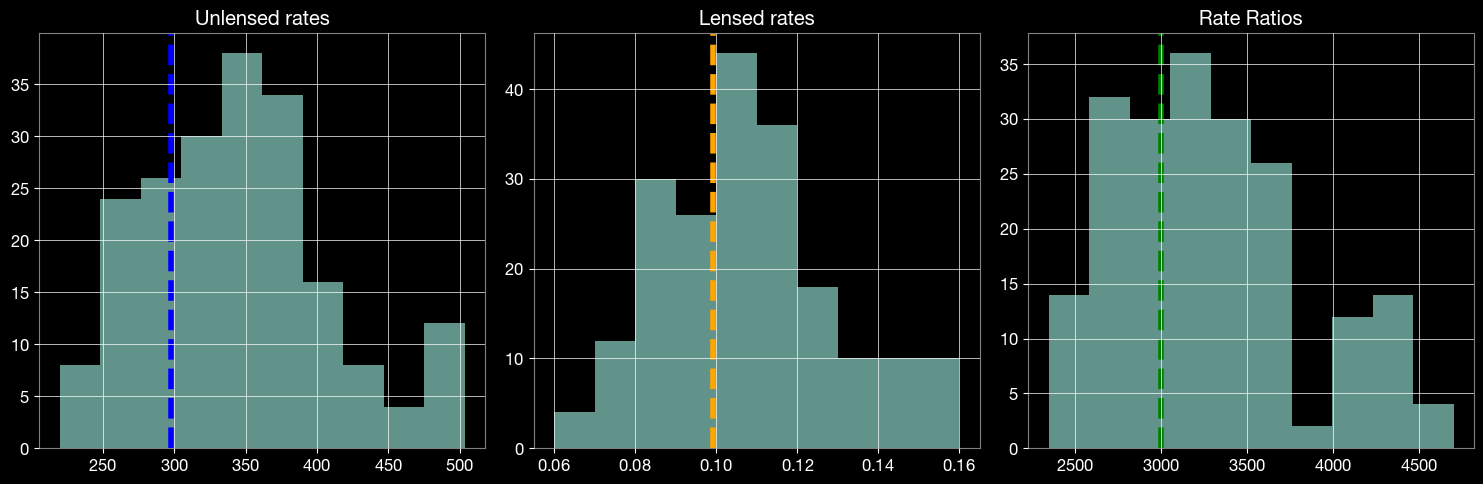

In [15]:
# plot the distribution of the rates and rate ratios
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.hist(unlensed_rates, bins=10, alpha=0.7)
# median value
ax1.axvline(unlensed_rate_median, color="blue", linestyle="--", linewidth=4)
ax1.set_title("Unlensed rates")

ax2.hist(lensed_rates, bins=10, alpha=0.7)
ax2.axvline(lensed_rate_median, color="orange", linestyle="--", linewidth=4)
ax2.set_title("Lensed rates")

ax3.hist(rate_ratios, bins=10, alpha=0.7)
ax3.axvline(rate_ratio_median, color="green", linestyle="--", linewidth=4)
ax3.set_title("Rate Ratios")

plt.tight_layout()
plt.show()

### 5.2 Source-mass distribution uncertainty

Overlay mass distributions from posterior realizations and compare against the median-hyperparameter reference distribution.

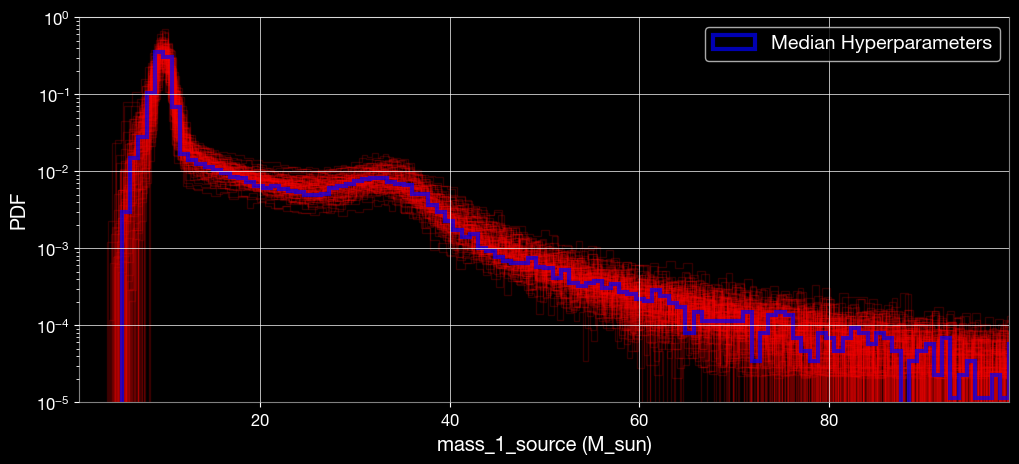

In [16]:
# Plot m1 distribution overlays using m1_samples_unlensed
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
bins = 300
# Plot many recalibrated sample histograms and their corresponding PDF estimates
for arr in m1_samples_unlensed:
    plt.hist(arr, bins=bins, density=True, alpha=0.1, color='r', histtype='step')

plt.hist(m1_samples_median, bins=bins, density=True, alpha=0.7, color='blue', histtype='step', label='Median Hyperparameters', linewidth=3)

legend = plt.legend(
    handlelength=2.2,
    loc='upper right',
    bbox_to_anchor=(1, 1),
    frameon=True,
    fontsize=14,
    edgecolor='lightgray'
)
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
for handle in legend.get_lines():
    handle.set_linewidth(1.6)
    handle.set_alpha(0.85)

plt.yscale('log')
plt.ylim(1e-5, 1.0)
plt.xlim(1, 99)
plt.xlabel('mass_1_source (M_sun)')
plt.ylabel('PDF')
plt.show()

---

## Summary

This notebook demonstrated how to propagate astrophysical mass-model uncertainty into LeR rate predictions.

1. Loaded posterior samples for the broken powerlaw + two peaks hyperparameters.
2. Built a median-hyperparameter baseline and computed unlensed/lensed rates.
3. Propagated posterior uncertainty through repeated LeR simulations.
4. Compared the baseline against posterior-driven distributions of rates and source masses.

This workflow provides uncertainty-aware rate estimates rather than a single deterministic rate value.